### Embedding Stability Graph

Uses the mean distances between vectors for one word to graph

Iterations - How many iterations files to use


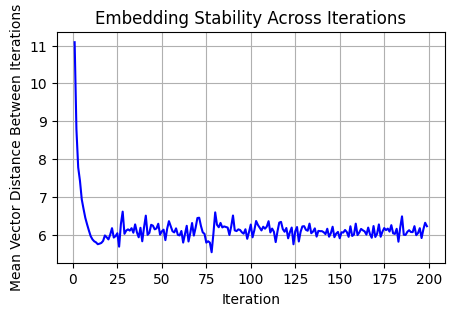

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt

Iterations = 200


# Load all embedding files
embeddings = []
for i in range(Iterations):
    with open(f'../data/iterative_vectors/window_4_iter_{i}.json', 'r') as f:
        embeddings.append(json.load(f))
words = embeddings[0].keys()
# Calculate average deviation between consecutive iterations
deviations = []
for i in range(len(embeddings)-1):
    distances = []
    for word in words:
        vec1 = np.array(embeddings[i][word])
        vec2 = np.array(embeddings[i+1][word])
        distance = np.linalg.norm(vec1 - vec2)
        distances.append(distance)
    
    # Store average deviation for this iteration
    deviations.append(np.mean(distances))

# Plot the results
plt.figure(figsize=(5, 3))
plt.plot(range(1, Iterations), deviations, 'b-')
plt.xlabel('Iteration')
plt.ylabel('Mean Vector Distance Between Iterations')
plt.title('Embedding Stability Across Iterations')
plt.grid(True)
plt.show()